# Analysis for 'count_chat_script.py'

#### Initial Descriptive Stats

1. Loading Data

Since the processed job ad data are stored in CSV files, first import the necessary libraries and read the data.

In [ ]:
import pandas as pd
import os

# Set the path to the processed CSV files
DATA_FOLDER = "processed_data_preprocessed"  # Update if needed

# Get list of CSV files in the folder
csv_files = [file for file in os.listdir(DATA_FOLDER) if file.endswith(".csv")]

# Load each file into a DataFrame and collect them
df_list = []
for file in csv_files:
    file_path = os.path.join(DATA_FOLDER, file)
    try:
        df_part = pd.read_csv(file_path, encoding="utf-8")
        df_list.append(df_part)
    except Exception as e:
        print(f"Failed to load {file}: {e}")

# Merge all DataFrames
df_all = pd.concat(df_list, ignore_index=True)

# Display and save preview
print(df_all.head())
df_all.head().to_csv("head_of_data.csv", index=False, encoding="utf-8")

# Save the merged DataFrame to a CSV file

df_all.to_csv("df_desc.csv", index=False, encoding="utf-8")

   summary_AutomatchType  summary_Abroad  summary_Weight  \
0                      0           False               1   
1                      0           False               1   
2                      0           False               1   
3                      0           False               1   
4                      0           False               1   

                                       summary_Title  \
0  Træd speederen i bund og bliv teknisk rådgiver...   
1  LindbergHR søger regnskabskonsulent med et par...   
2  Fængselslærer til institution Sdr. Omme - Sdr....   
3  Social- og sundhedsassistent til dagvagt 35 ti...   
4  BØRNEHUSET VANDET SØGER EN PÆDAGOG, FASTANSÆTT...   

                                 summary_JobHeadline  \
0  Træd speederen i bund og bliv teknisk rådgiver...   
1  LindbergHR søger regnskabskonsulent med et par...   
2  Fængselslærer til institution Sdr. Omme - Sdr....   
3  Social- og sundhedsassistent til dagvagt 35 ti...   
4  BØRNEHUSET VANDET S

In [ ]:
# Load the saved preview (if needed to check output)

#df_head = pd.read_csv("head_of_data.csv")

#last: 0.3s

2. Validation

Checking for duplicates, missing values, empty columns

In [ ]:
# Check for Duplicates
df_all.duplicated().sum()

0

In [ ]:
# If needed, remove duplicates
#df_all = df_all.drop_duplicates()

In [ ]:
# Drop empty columns and show which ones were removed
before_cols = df_all.shape[1]
empty_cols = df_all.columns[df_all.isna().all()].tolist()
df_all = df_all.drop(columns=empty_cols)
after_cols = df_all.shape[1]

print(f"Removed {before_cols - after_cols} completely empty columns.")
if empty_cols:
    print("Dropped columns:")
    for col in empty_cols:
        print(f" - {col}")
else:
    print("No completely empty columns were found.")


Removed 45 completely empty columns.
Dropped columns:
 - summary_PostalCodeName
 - details_JobPositionPosting_HiringOrg_FaxNumber
 - details_JobPositionPosting_RecruitingCompany
 - details_JobPositionPosting_JobPositionInformation_WeeklyWorkHours_Description
 - details_JobPositionPosting_JobPositionInformation_CompensationDescription
 - details_JobLogTemplateModel_CvCustomerIdentifier
 - details_JobLogTemplateModel_JobSeekingStatus
 - details_JobLogTemplateModel_ApplicationSource
 - details_JobLogTemplateModel_HoursPerWeek
 - details_JobLogTemplateModel_JobAdDocument_Title
 - details_JobLogTemplateModel_JobAdDocument_Identifier
 - details_JobLogTemplateModel_JobAdFile
 - details_JobLogTemplateModel_Company_Country
 - details_JobLogTemplateModel_Company_EmploymentAreaID
 - details_JobLogTemplateModel_Company_Latitude
 - details_JobLogTemplateModel_Company_Longitude
 - details_JobLogTemplateModel_Company_DailyTravelTimeInMinutes
 - details_JobLogTemplateModel_Company_DistanceToCompanyInM

In [ ]:
## Check for mising values 
# Create null summary
null_summary = df_all.isnull().sum().reset_index()
null_summary.columns = ["Column", "Missing_Values"]
null_summary = null_summary.sort_values(by="Missing_Values", ascending=False)

# Create stats_outputs folder if it doesn't exist
output_stats_dir = "stats_outputs"
os.makedirs(output_stats_dir, exist_ok=True)

# Define full path to the output file
output_path = os.path.join(output_stats_dir, "null_summary.csv")

# Save to CSV
null_summary.to_csv(output_path, index=False, encoding="utf-8")

print(f"Missing value summary saved to '{output_path}'")

print(null_summary.head(10))

Missing value summary saved to 'stats_outputs/null_summary.csv'
                                                Column  Missing_Values
132  details_JobPositionPosting_ApplicationDetails_...           24659
200  details_JobPositionPosting_ContactAuthorityPho...           24656
63                         details_WorkPlace_FaxNumber           24652
216  details_JobPositionPosting_RecruitingCompany_W...           24439
209  details_JobPositionPosting_RecruitingCompany_A...           24403
217  details_JobPositionPosting_RecruitingCompany_W...           24393
206  details_JobPositionPosting_RecruitingCompany_A...           24393
215  details_JobPositionPosting_RecruitingCompany_F...           24239
218  details_JobPositionPosting_RecruitingCompany_O...           24141
208  details_JobPositionPosting_RecruitingCompany_A...           23876


3. Quick Info

This will give an overview of columns, data types, and missing values. Mostly here as a sanity check.

In [ ]:
df_info = df_all.info()

from IPython.display import display

display(df_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24668 entries, 0 to 24667
Columns: 219 entries, summary_AutomatchType to details_JobPositionPosting_RecruitingCompany_OrganizationNumber
dtypes: bool(45), float64(38), int64(24), object(112)
memory usage: 33.8+ MB


None

4. Summary Statistics

To get a summary of the columns in the dataset.

In [ ]:
#df_all.describe()

# For categorical columns

df_categorical_summary = df_all.describe(include="object")

from IPython.display import display

display(df_categorical_summary)

# last: 11.3s


,summary_Title,summary_JobHeadline,summary_Presentation,summary_HiringOrgName,summary_WorkPlaceAddress,summary_WorkPlaceCity,summary_PostingCreated,summary_LastDateApplication,summary_FormattedLastDateApplication,summary_AssignmentStartDate,...,details_MapUrl,text_preprocessed,details_JobPositionPosting_ContactAuthorityPhoneNumber_Description,details_JobPositionPosting_RecruitingCompany_Name,details_JobPositionPosting_RecruitingCompany_Address_AddressLine,details_JobPositionPosting_RecruitingCompany_Address_Country_Name,details_JobPositionPosting_RecruitingCompany_Address_Region_Name,details_JobPositionPosting_RecruitingCompany_Address_City,details_JobPositionPosting_RecruitingCompany_PhoneNumber_Description,details_JobPositionPosting_RecruitingCompany_WebAddress
count,24668,24668,24632,24668,21819,23757,24668,24668,24668,24668,...,24668,24668,14617,847,802,275,265,802,802,229
unique,23589,23589,23199,6922,11263,568,5802,870,128,1,...,11605,24242,1,90,55,1,4,55,1,40
top,Rengøringsassistent,Rengøringsassistent,Kunne du tænke dig at få muligheden for at ska...,Københavns Kommune,,København NV,2022-05-04T00:00:00,2022-05-31T00:00:00,16. februar 2025,0001-01-01T00:00:00,...,https://www.google.dk/maps/place/Borups+Allé+1...,jobbet du vil skulle støtte og afløse off-trad...,Primary,Jobcenter Lolland,Lillievej 4,Danmark,Syddanmark,Nakskov,Primary,http://silkeborgkommune.dk/
freq,25,25,66,806,654,898,1270,873,948,24668,...,462,19,14617,46,66,275,84,66,802,26


5. Distribution of Job Titles

List the amount of each job title, and how many unique job titles there are

In [ ]:
# Get job title counts
job_title_counts = df_all["summary_Occupation"].value_counts()

# Display the full list
print(job_title_counts)

# Count unique job titles
num_unique_titles = df_all["summary_Occupation"].nunique()
print(f"Total distinct job titles: {num_unique_titles}")

# Save to stats_outputs
output_stats_dir = "stats_outputs"
os.makedirs(output_stats_dir, exist_ok=True)

# Convert to DataFrame for saving
job_title_counts_df = job_title_counts.reset_index()
job_title_counts_df.columns = ["Job Title", "Count"]

# Save to CSV
output_path = os.path.join(output_stats_dir, "job_title_counts.csv")
job_title_counts_df.to_csv(output_path, index=False, encoding="utf-8")

print(f"Job title counts saved to '{output_path}'")




summary_Occupation
Pædagog                                           1610
Sygeplejerske                                     1258
Social- og sundhedsassistent                      1232
Social- og sundhedshjælper                         766
Folkeskolelærer                                    593
                                                  ... 
Lektor                                               1
Lektor, professionshøjskole og erhvervsakademi       1
Forsikringselev                                      1
Lektor, humaniora                                    1
Redaktør                                             1
Name: count, Length: 799, dtype: int64
Total distinct job titles: 799
Job title counts saved to 'stats_outputs/job_title_counts.csv'


6. Plotting Descriptive Statistics

Creating visualizations to explore the data.

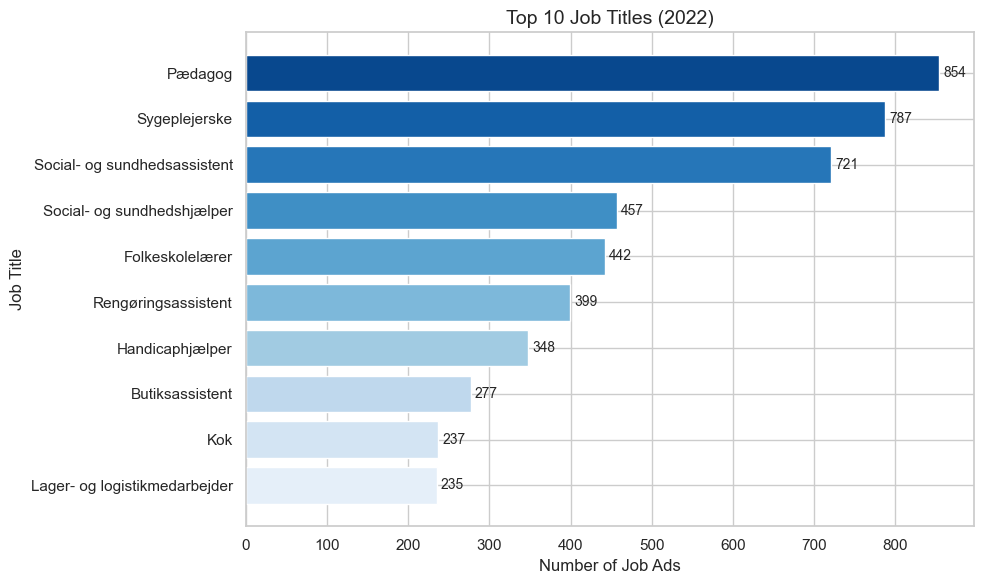

Plot saved to 'plot_outputs/top_10_job_titles_2022.png'


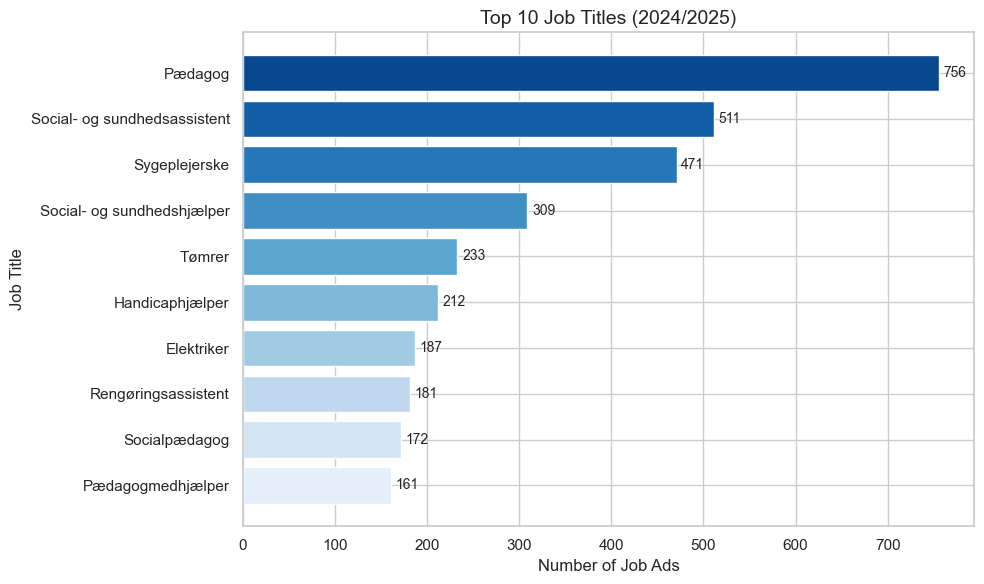

Plot saved to 'plot_outputs/top_10_job_titles_2024_2025.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directory
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Ensure datetime format and assign period group
df_all["summary_PostingCreated"] = pd.to_datetime(df_all["summary_PostingCreated"], errors='coerce')
df_all["Posting_Year"] = df_all["summary_PostingCreated"].dt.year
df_all["Period_Group"] = df_all["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Function to create and save a bar plot
def plot_top_job_titles(period_label, output_filename, color_palette="Blues"):
    subset = df_all[df_all["Period_Group"] == period_label]
    job_counts = subset["summary_Occupation"].value_counts().head(10)[::-1]
    colors = sns.color_palette(color_palette, n_colors=10)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(job_counts.index, job_counts.values, color=colors)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
                 f'{int(width)}', va='center', fontsize=10)

    plt.title(f"Top 10 Job Titles ({period_label})", fontsize=14)
    plt.xlabel("Number of Job Ads")
    plt.ylabel("Job Title")
    plt.tight_layout()

    plot_path = os.path.join(output_plot_dir, output_filename)
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Plot saved to '{plot_path}'")

# Generate one plot per period
plot_top_job_titles("2022", "top_10_job_titles_2022.png")
plot_top_job_titles("2024/2025", "top_10_job_titles_2024_2025.png")


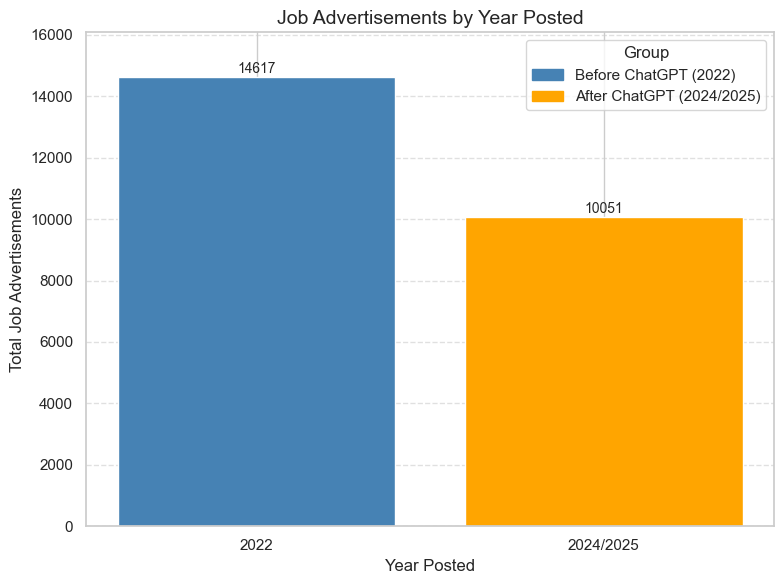

Plot saved to: plot_outputs/yearly_job_postings_grouped.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

# Convert to datetime and extract year
posting_dates = pd.to_datetime(df_all["summary_PostingCreated"], errors="coerce")
years = posting_dates.dt.year

# Group years into pre/post ChatGPT categories
grouped_years = years.apply(lambda y: "2022" if y == 2022 else ("2024/2025" if y in [2024, 2025] else None))
df_grouped = grouped_years.value_counts().sort_index()

# Define bar colors
bar_colors = ["steelblue" if year == "2022" else "orange" for year in df_grouped.index]

# Output directory
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(df_grouped.index, df_grouped.values, color=bar_colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 50, f"{int(height)}", ha='center', va='bottom', fontsize=10)

# Labels and formatting
ax.set_title("Job Advertisements by Year Posted", fontsize=14)
ax.set_xlabel("Year Posted")
ax.set_ylabel("Total Job Advertisements")
ax.set_ylim(0, max(df_grouped.values) * 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Add legend
legend_handles = [
    Patch(color="steelblue", label="Before ChatGPT (2022)"),
    Patch(color="orange", label="After ChatGPT (2024/2025)")
]
ax.legend(handles=legend_handles, title="Group")

# Save plot
output_path = os.path.join(output_plot_dir, "yearly_job_postings_grouped.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to: {output_path}")


Saved: plot_outputs/word_cloud_titles_2022.png
Saved: plot_outputs/word_cloud_titles_2024_2025.png


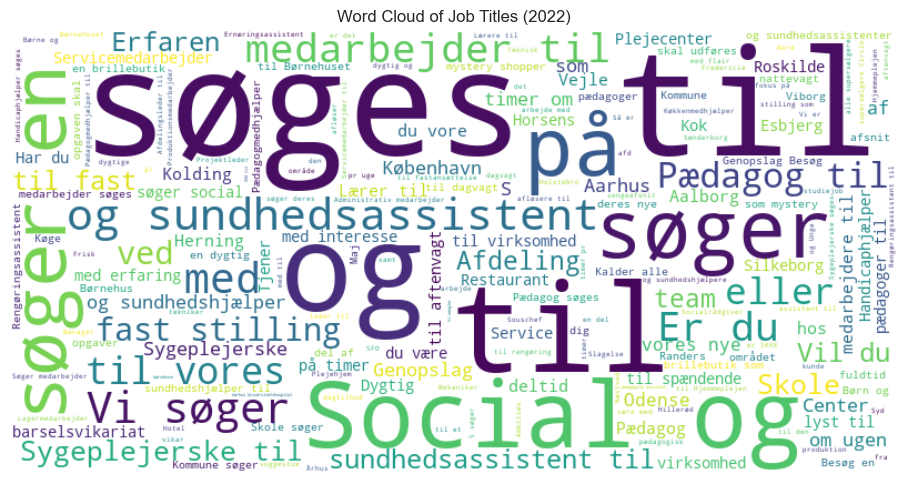

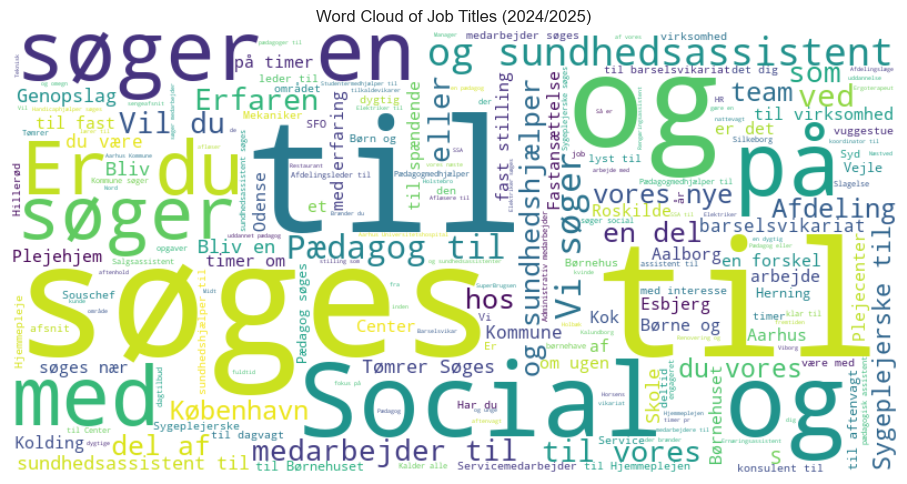

In [ ]:
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Ensure output directory exists
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Convert posting date to datetime and extract year
df_all["summary_PostingCreated"] = pd.to_datetime(df_all["summary_PostingCreated"], errors="coerce")
df_all["Posting_Year"] = df_all["summary_PostingCreated"].dt.year

# Group by period
df_all["Period_Group"] = df_all["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Function to create and save word cloud
def generate_wordcloud(texts, title, filename):
    text = " ".join(texts.dropna())
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    
    path = os.path.join(output_plot_dir, filename)
    plt.savefig(path, dpi=300)
    #plt.close()
    print(f"Saved: {path}")

# Generate for each period
generate_wordcloud(
    df_all[df_all["Period_Group"] == "2022"]["summary_Title"],
    "Word Cloud of Job Titles (2022)",
    "word_cloud_titles_2022.png"
)

generate_wordcloud(
    df_all[df_all["Period_Group"] == "2024/2025"]["summary_Title"],
    "Word Cloud of Job Titles (2024/2025)",
    "word_cloud_titles_2024_2025.png"
)

#last: 9.7s

In [ ]:
# Save a csv of the dataframe as it looks now after running the above chunks:

df_all.to_csv("df_desc_filt.csv", index=False, encoding="utf-8")

#### Some more specific descriptive stats

1. Load Data & Preprocess

Ensure the dataset is loaded correctly, assuming there is a CSV with a column for job descriptions and a column for the year.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from textstat import flesch_reading_ease

# Ensure NLTK resources are available
nltk.download('punkt')
nltk.download('stopwords')

# Load your preprocessed dataset
df_copy = pd.read_csv("df_desc_filt.csv") #this loads a csv file that is only available if you have run the chunks above

# Optional: keep only needed columns here to reduce memory
# df = df[["text_preprocessed", "summary_PostingCreated", "summary_Occupation"]]



[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_16392/389838119.py:17: DtypeWarning: Columns (132,134) have mixed types. Specify dtype option on import or set low_memory=False.
  df_copy = pd.read_csv("df_desc_filt.csv") #this loads a csv file that is only available if you have run the chunks above


2. Word Count Distribution Analysis

                count        mean         std   min    25%    50%    75%  \
Period_Group                                                               
2022          14617.0  463.651707  253.854751  18.0  262.0  436.0  627.0   
2024/2025     10051.0  536.953736  264.634226  20.0  325.5  516.0  709.0   

                 max  
Period_Group          
2022          2275.0  
2024/2025     1935.0  


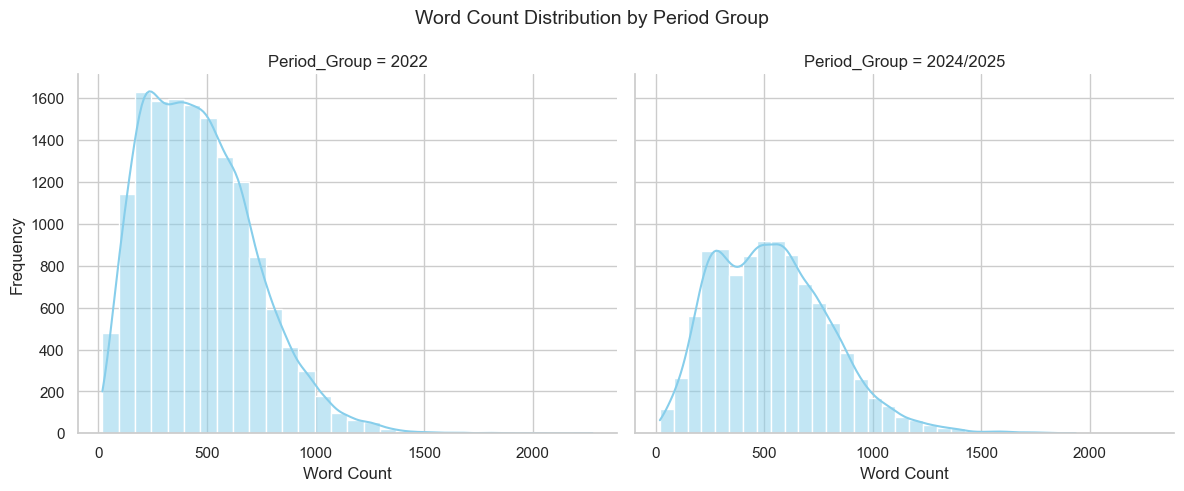

Plot saved to 'plot_outputs/word_count_distribution_by_period_group.png'


In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import pandas as pd

# Create output folder
output_plots_dir = "plot_outputs"
os.makedirs(output_plots_dir, exist_ok=True)

# Copy and preprocess
df_wc = df_all.copy() #Renaming df to _wc (word count) to avoid confusion
df_wc["summary_PostingCreated"] = pd.to_datetime(df_wc["summary_PostingCreated"], errors="coerce").dt.tz_localize(None)
df_wc["Posting_Year"] = df_wc["summary_PostingCreated"].dt.year
df_wc["Period_Group"] = df_wc["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Filter to valid periods
df_wc_grouped = df_wc[df_wc["Period_Group"].notnull()].copy()

# Compute word counts
df_wc_grouped["word_count"] = df_wc_grouped["details_JobPositionPosting_JobPositionInformation_Purpose"].apply(
    lambda x: len(word_tokenize(x)) if pd.notnull(x) else 0
)

# Summary statistics
print(df_wc_grouped.groupby("Period_Group")["word_count"].describe())

# Faceted histogram
g = sns.FacetGrid(
    df_wc_grouped,
    col="Period_Group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "word_count", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Word Count", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Word Count Distribution by Period Group", fontsize=14)

# Save
output_path = os.path.join(output_plots_dir, "word_count_distribution_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")


In [ ]:
# Create output folder
output_stats_dir = "stats_outputs"
os.makedirs(output_stats_plots_dir, exist_ok=True)

# Filter job ads with 20 words or fewer
df_short = df_grouped[df_grouped["word_count"] <= 10]

# Define output path
short_output_path = os.path.join(output_stats_dir, "job_ads_10.csv")

# Save to CSV
df_short.to_csv(short_output_path, index=False, encoding="utf-8")

print(f"Filtered dataset saved to: {short_output_path}")
print(f"Number of short ads (<=10 words): {len(df_short)}")


Filtered dataset saved to: plot_outputs/job_ads_10.csv
Number of short ads (<=10 words): 0


Original sample size: 24668
Sample size after removing outliers: 24432


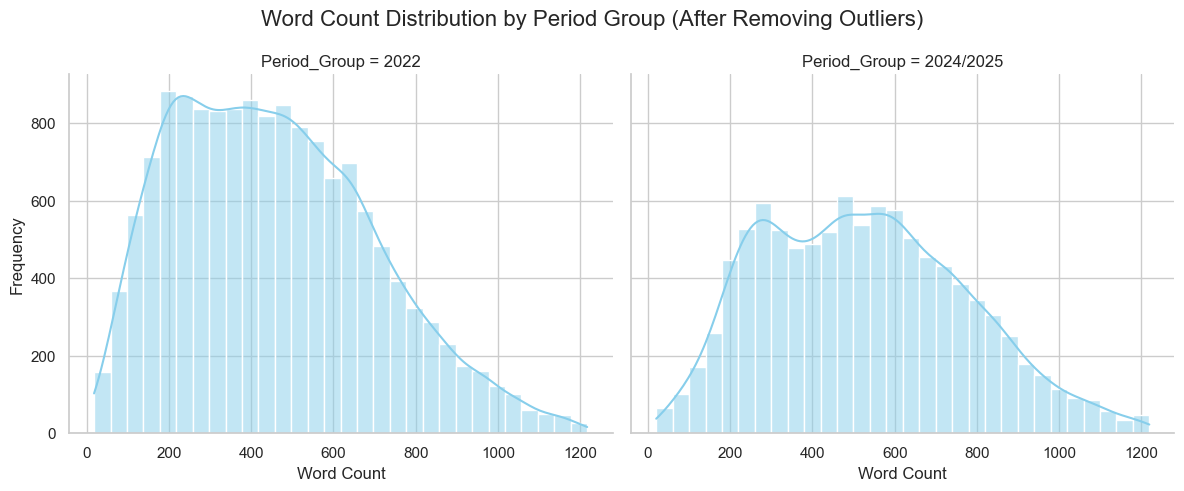

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize

# --- Setup your dataframe ---

# Assume df_grouped already exists from your previous code
# If not, make sure you first load and process your data as before

# --- Step 1: Define a function to filter outliers using IQR ---
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# --- Step 2: Apply the function to remove word count outliers ---
df_no_outliers = remove_outliers_iqr(df_grouped, "word_count")

print(f"Original sample size: {len(df_grouped)}")
print(f"Sample size after removing outliers: {len(df_no_outliers)}")

# --- Step 3: Plot word count distribution by Period Group (no outliers) ---
sns.set(style="whitegrid")

g = sns.FacetGrid(
    df_no_outliers, 
    col="Period_Group", 
    height=5, 
    aspect=1.2, 
    col_order=["2022", "2024/2025"],  # enforce order, 
    sharex=True, 
    sharey=True)
g.map(sns.histplot, "word_count", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Word Count", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Word Count Distribution by Period Group (After Removing Outliers)", fontsize=16)

plt.show()


In [ ]:
# Check if descriptions start with http or www
df_links = df_grouped[
    df_grouped["details_JobPositionPosting_JobPositionInformation_Purpose"].str.startswith(("http", "www"), na=False)
]

# Define output path
links_output_path = os.path.join(output_dir, "job_ads_starting_with_links.csv")

# Save to CSV
df_links.to_csv(links_output_path, index=False, encoding="utf-8")

print(f"Filtered dataset saved to: {links_output_path}")

print(df_links.head(10))



Filtered dataset saved to: plot_outputs/job_ads_starting_with_links.csv


In [ ]:
#df_grouped[df_grouped["word_count"] <= 20]["details_JobPositionPosting_JobPositionInformation_Purpose"].sample(10).to_list()


ValueError: Cannot take a larger sample than population when 'replace=False'

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_93932/4047468317.py:6: DtypeWarning: Columns (137,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df_copy1 = pd.read_csv("df_desc.csv")


KeyError: 'word_count'

In [ ]:
## creating series to use for statistical tests and some visualisations like box-plots

#make sure to run the above chunk before this one

# Create separate groups
group_2022 = df_wc_grouped[df_grouped["Period_Group"] == "2022"]["word_count"].dropna()
group_2024_2025 = df_wc_grouped[df_wc_grouped["Period_Group"] == "2024/2025"]["word_count"].dropna()


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_16392/4183246030.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


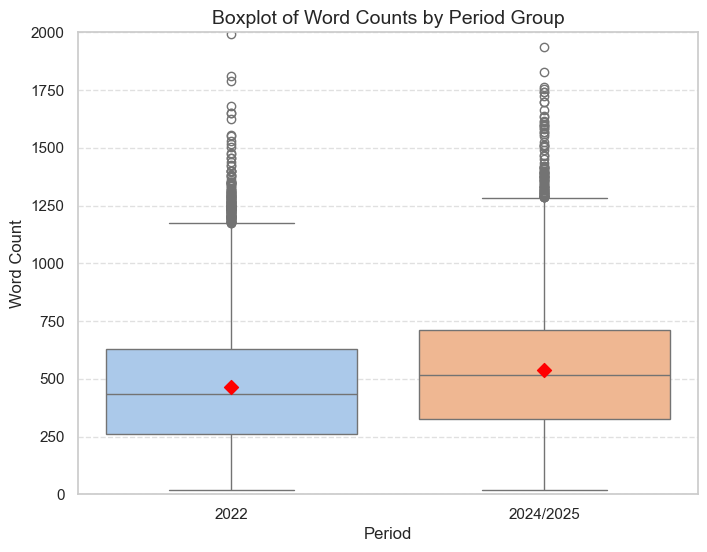

Boxplot saved to: plot_outputs/word_count_boxplot_by_period_group.png


In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Plot setup
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_wc_grouped,
    x='Period_Group',
    y='word_count',
    order=["2022", "2024/2025"],
    palette='pastel'
)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = df_wc_grouped.groupby("Period_Group")["word_count"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, marker='D', s=50)

# Axis and title
plt.title("Word Count by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("Word Count")
plt.ylim(0, 2000)

# Save and show
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "word_count_boxplot_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Boxplot saved to: {output_path}")


In [ ]:
# Calculate IQR for each group separately
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

# Find outliers in each group
outliers_2022 = detect_outliers_iqr(group_2022)
outliers_2024_2025 = detect_outliers_iqr(group_2024_2025)

print(f"Number of outliers in 2022: {len(outliers_2022)}")
print(f"Number of outliers in 2024/2025: {len(outliers_2024_2025)}")


Number of outliers in 2022: 172
Number of outliers in 2024/2025: 118


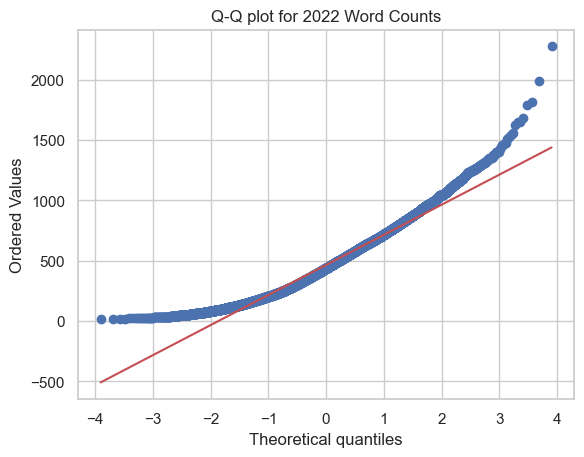

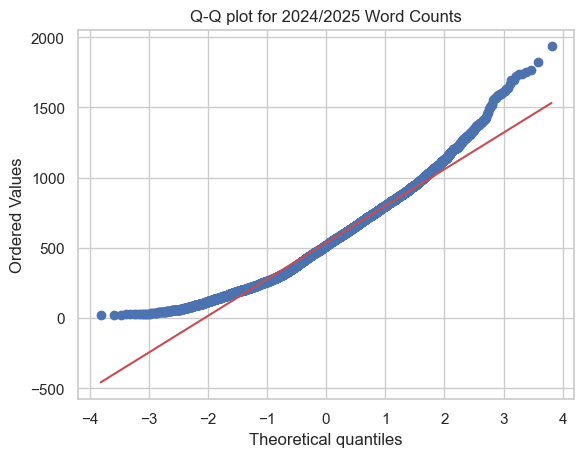

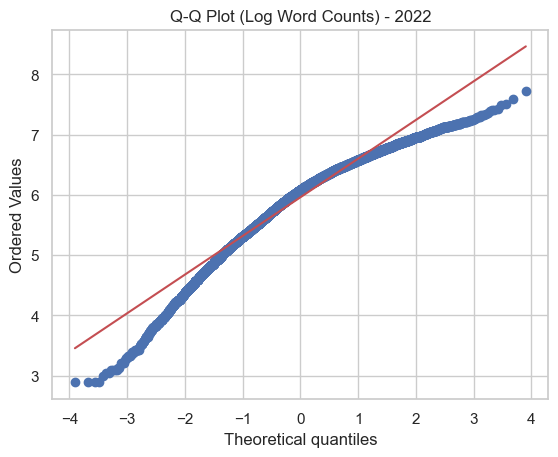

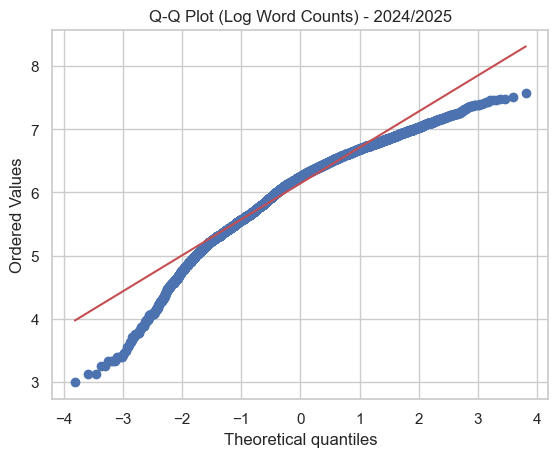

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# For 2022
stats.probplot(group_2022, dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Word Counts")
plt.show()

# For 2024/2025
stats.probplot(group_2024_2025, dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Word Counts")
plt.show()

import numpy as np

# Q-Q plot with log-transformed word counts
stats.probplot(np.log(group_2022), dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Word Counts) - 2022")
plt.show()

stats.probplot(np.log(group_2024_2025), dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Word Counts) - 2024/2025")
plt.show()


In [ ]:
from scipy.stats import levene

# Run Levene's test
stat, p_value = levene(group_2022, group_2024_2025)

print(f"Levene's test statistic: {stat:.3f}")
print(f"Levene's test p-value: {p_value:.6f}")

# Run Levene's test WITH LOG
stat, p_value = levene(np.log(group_2022), np.log(group_2024_2025))

print(f"Levene's test statistic: {stat:.3f}")
print(f"Levene's test p-value: {p_value:.6f}")


Levene's test statistic: 17.101
Levene's test p-value: 0.000036
Levene's test statistic: 132.417
Levene's test p-value: 0.000000


In [ ]:
## Welsch T-Test

from scipy.stats import ttest_ind

# Assuming you have these defined:
# group_2022 and group_2024_2025 are the word counts for each period

statistic, p_value = ttest_ind(group_2022, group_2024_2025, equal_var=False)

print(f"Welch's t-test statistic: {statistic:.3f}")
print(f"p-value: {p_value:.6f}")

## WITH LOG
statistic, p_value = ttest_ind(np.log(group_2022), np.log(group_2024_2025), equal_var=False)

print(f"Welch's t-test statistic: {statistic:.3f}")
print(f"p-value: {p_value:.6f}")


Welch's t-test statistic: -21.733
p-value: 0.000000
Welch's t-test statistic: -23.022
p-value: 0.000000


In [ ]:
## Cohens d

import numpy as np

# Means
mean_2022 = group_2022.mean()
mean_2024_2025 = group_2024_2025.mean()

# Standard deviations
std_2022 = group_2022.std()
std_2024_2025 = group_2024_2025.std()

# Sample sizes
n_2022 = len(group_2022)
n_2024_2025 = len(group_2024_2025)

# Pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")

## WITH LOG
# Means
mean_2022 = np.log(group_2022).mean()
mean_2024_2025 = np.log(group_2024_2025).mean()

# Standard deviations
std_2022 = np.log(group_2022).std()
std_2024_2025 = np.log(group_2024_2025).std()

# Sample sizes
n_2022 = len(np.log(group_2022))
n_2024_2025 = len(np.log(group_2024_2025))

# Pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")


Cohen's d: -0.284
Cohen's d: -0.292


In [ ]:

## running a non-parametric test as a robustness check
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(group_2022, group_2024_2025, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p:.6f}")

# WITH LOG
stat, p = mannwhitneyu(np.log(group_2022), np.log(group_2024_2025), alternative='two-sided')
print(f"Mann-Whitney U p-value: {p:.6f}")


Mann-Whitney U p-value: 0.000000
Mann-Whitney U p-value: 0.000000


3. Lexical Diversity

Lexical diversity is the ratio of unique words to total words in a text.

                count      mean       std       min       25%       50%  \
Period_Group                                                              
2022          14617.0  0.556604  0.088704  0.234770  0.494290  0.541547   
2024/2025     10051.0  0.532009  0.078342  0.226082  0.477899  0.518697   

                   75%  max  
Period_Group                 
2022          0.603279  1.0  
2024/2025     0.573980  1.0  


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_16392/3535891471.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


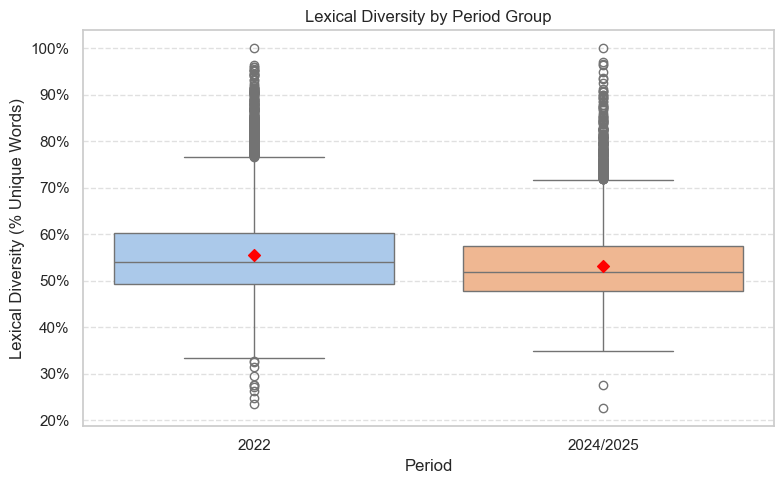

Lexical diversity plot saved to: plot_outputs/lexical_diversity_by_period_group.png


In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import pandas as pd
import matplotlib.ticker as mtick

# Copy the original dataframe
df_ld = df_all.copy()

# Convert date to datetime and extract year
df_ld['summary_PostingCreated'] = pd.to_datetime(df_ld['summary_PostingCreated'], errors='coerce').dt.tz_localize(None)
df_ld['Posting_Year'] = df_ld['summary_PostingCreated'].dt.year

# Group years
df_ld['Period_Group'] = df_ld['Posting_Year'].apply(
    lambda x: '2022' if x == 2022 else ('2024/2025' if x in [2024, 2025] else None)
)

# Filter out NaNs from the period group
df_ld_grouped = df_ld[df_ld['Period_Group'].notnull()]

# Compute lexical diversity
def lexical_diversity(text):
    words = word_tokenize(text)
    return len(set(words)) / len(words) if len(words) > 0 else 0

df_ld_grouped['lexical_diversity'] = df_ld_grouped['details_JobPositionPosting_JobPositionInformation_Purpose'].dropna().apply(lexical_diversity)

# Summary stats
print(df_ld_grouped.groupby('Period_Group')['lexical_diversity'].describe())

# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_ld_grouped,
    x='Period_Group',
    y='lexical_diversity',
    order=["2022", "2024/2025"],
    palette='pastel'
)

# Gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = df_ld_grouped.groupby("Period_Group")["lexical_diversity"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, label='Mean' if i == 0 else "", marker='D')

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylabel("Lexical Diversity (% Unique Words)")

# Final touches
plt.title("Lexical Diversity by Period Group")
plt.xlabel("Period")
plt.tight_layout()

# Save
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "lexical_diversity_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Lexical diversity plot saved to: {output_path}")


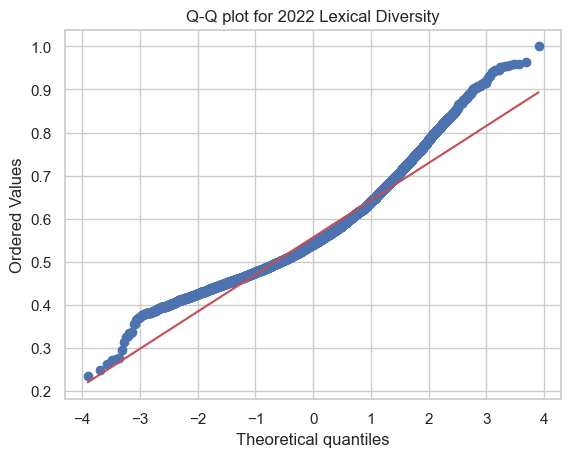

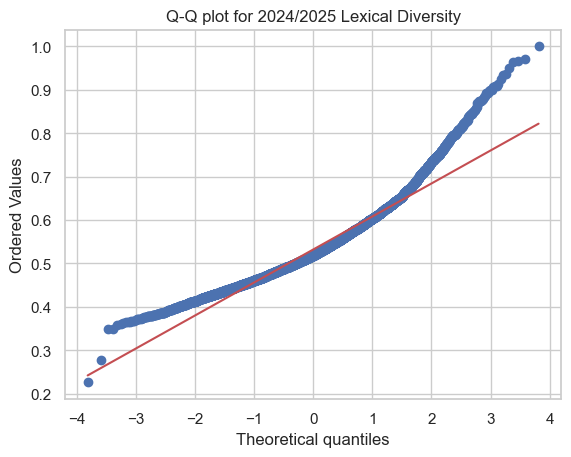

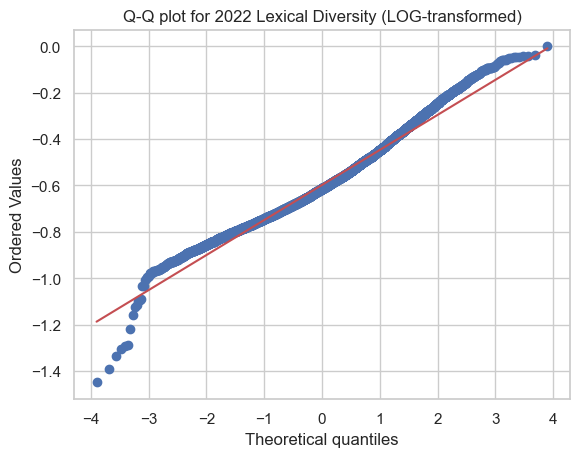

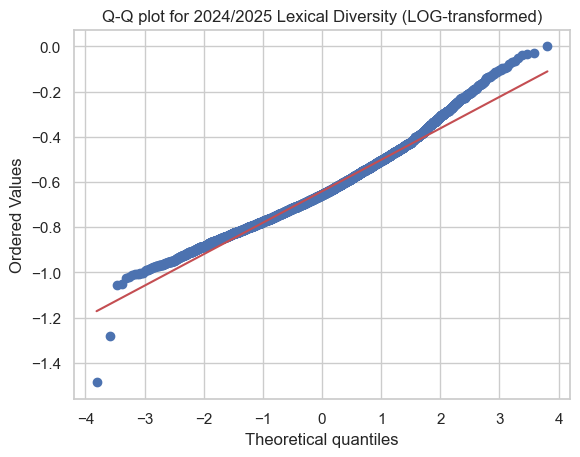

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# Subset the data
group_2022 = df_ld_grouped[df_ld_grouped['Period_Group'] == '2022']['lexical_diversity'].dropna()
group_2024_2025 = df_ld_grouped[df_ld_grouped['Period_Group'] == '2024/2025']['lexical_diversity'].dropna()

# Q-Q plot for 2022
stats.probplot(group_2022, dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Lexical Diversity")
plt.show()

# Q-Q plot for 2024/2025
stats.probplot(group_2024_2025, dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Lexical Diversity")
plt.show()

## With log-transformation

# Subset the data
group_2022 = df_ld_grouped[df_ld_grouped['Period_Group'] == '2022']['lexical_diversity'].dropna()
group_2024_2025 = df_ld_grouped[df_ld_grouped['Period_Group'] == '2024/2025']['lexical_diversity'].dropna()

# Q-Q plot for 2022
stats.probplot(np.log(group_2022), dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Lexical Diversity (LOG-transformed)")
plt.show()

# Q-Q plot for 2024/2025
stats.probplot(np.log(group_2024_2025), dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Lexical Diversity (LOG-transformed)")
plt.show()

4. Readability Scores (Flesch-Kincaid)

A lower score means harder-to-read text, while a higher score means easier readability.

                count       mean        std    min    25%    50%    75%  \
Period_Group                                                              
2022          14617.0  58.542782  11.326841 -80.78  51.58  59.09  65.76   
2024/2025     10051.0  57.314318  10.592651 -50.67  50.87  57.57  64.61   

                 max  
Period_Group          
2022          102.20  
2024/2025      95.47  


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_16392/1831997452.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped, x="Period_Group", y="readability", palette="Set2")


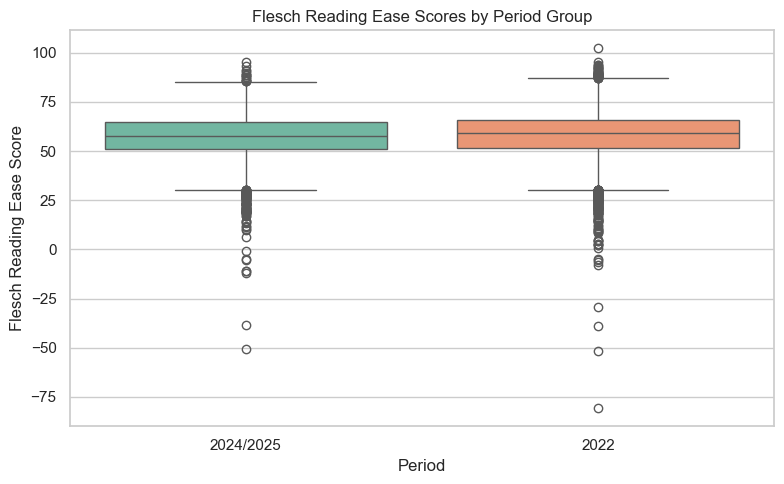

Readability plot saved to: plot_outputs/readability_scores_by_period_group.png


In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
from textstat import flesch_reading_ease
import pandas as pd

# Copy df to avoid modifying the original
df_rs = df_all.copy()

# Convert date to datetime and remove timezone info if present
df_rs["summary_PostingCreated"] = pd.to_datetime(df_rs["summary_PostingCreated"], errors="coerce").dt.tz_localize(None)
df_rs["Posting_Year"] = df_rs["summary_PostingCreated"].dt.year

# Group years into 2022 vs 2024/2025
df_rs["Period_Group"] = df_rs["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Filter valid periods and drop NaN texts
df_rs_grouped = df_rs[df_rs["Period_Group"].notnull()].copy()
df_rs_grouped = df_rs_grouped[df_rs_grouped["details_JobPositionPosting_JobPositionInformation_Purpose"].notnull()]

# Compute readability score
df_rs_grouped["readability"] = df_rs_grouped["details_JobPositionPosting_JobPositionInformation_Purpose"].apply(flesch_reading_ease)

# Optional: remove extreme outliers (filter scores below -100 for sanity)
df_rs_grouped = df_rs_grouped[df_rs_grouped["readability"] > -100]

# Summary stats
print(df_rs_grouped.groupby("Period_Group")["readability"].describe())

# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_rs_grouped, x="Period_Group", y="readability", palette="Set2")
plt.title("Flesch Reading Ease Scores by Period Group")
plt.xlabel("Period")
plt.ylabel("Flesch Reading Ease Score")
plt.tight_layout()

# Save plot
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "readability_scores_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Readability plot saved to: {output_path}")

#last: 1m 26.7s

5. Most Frequent Words

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Most common words in 2022:
[('kan', 53117), ('vores', 43134), ('arbejde', 28723), ('så', 24135), ('samt', 20453), ('stillingen', 20292), ('søger', 18986), ('ansøgning', 18487), ('erfaring', 16679), ('del', 16542), ('god', 15906), ('gode', 15859), ('samarbejde', 15823), ('ved', 15361), ('opgaver', 15195), ('både', 14831), ('dine', 14826), ('godt', 14635), ('mere', 14166), ('udvikling', 13806)]

Most common words in 2025:
[('kan', 38132), ('vores', 35496), ('arbejde', 21345), ('stillingen', 17680), ('så', 17354), ('del', 15144), ('samt', 14307), ('samarbejde', 14145), ('søger', 13686), ('ansøgning', 13666), ('opgaver', 13292), ('erfaring', 13282), ('både', 13082), ('dine', 12982), ('gode', 12076), ('ved', 12049), ('2025', 11790), ('arbejder', 11515), ('udvikling', 11356), ('mulighed', 10777)]

Most common words in 2024:
[('vores', 1572), ('kan', 1385), ('arbejde', 875), ('så', 756), ('søger', 631), ('del', 597), ('erfaring', 545), ('ansøgning', 541), ('dine', 525), ('mulighed', 505), ('

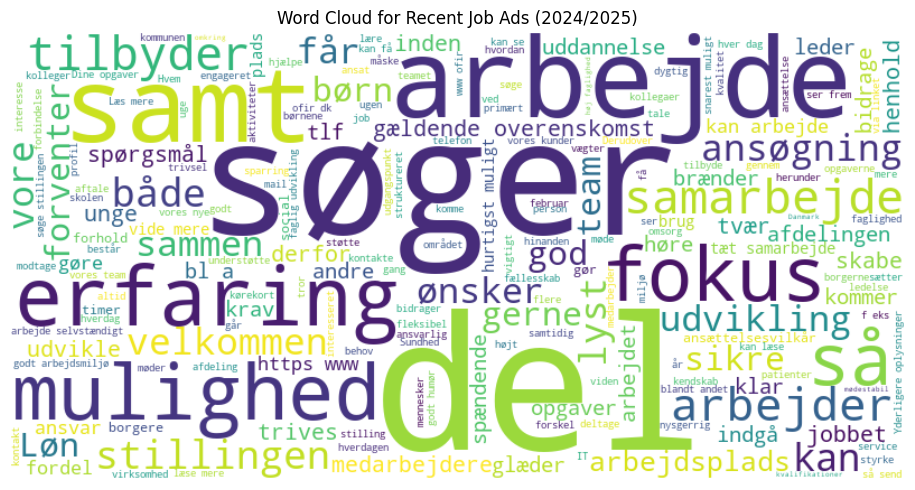

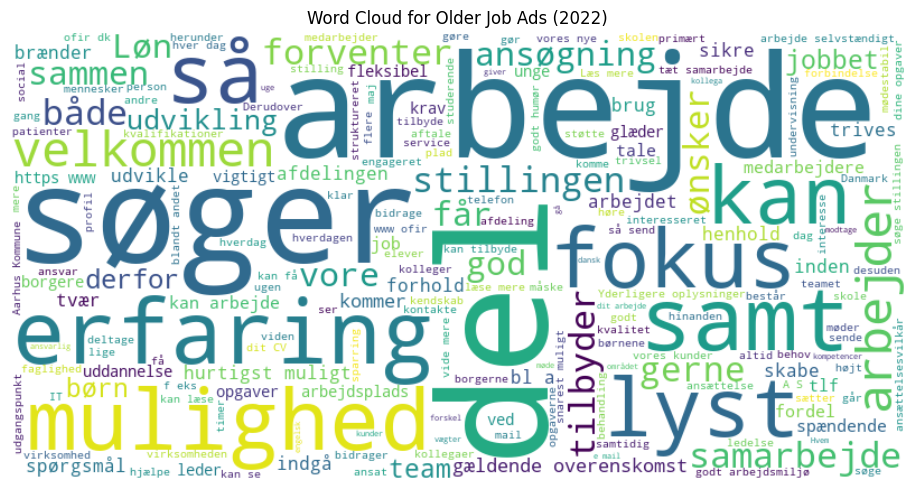

Word clouds saved to:
- plot_outputs/word_cloud_recent_ads_2024_2025.png
- plot_outputs/word_cloud_older_ads_2022.png


In [ ]:
import os
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

# Create output directory if it doesn't exist
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)

# Ensure stopwords are downloaded (if not already)
nltk.download('punkt')
nltk.download('stopwords')

# Define Danish stopwords
stop_words = set(stopwords.words('danish'))

# Convert posting date column to datetime and extract year
df["summary_PostingCreated"] = pd.to_datetime(df["summary_PostingCreated"], errors="coerce")
df["Posting_Year"] = df["summary_PostingCreated"].dt.year

# Function to get most common words
def get_most_common_words(texts, n=20):
    words = []
    for text in texts.dropna():
        words.extend([word.lower() for word in word_tokenize(text) if word.isalnum() and word.lower() not in stop_words])
    return Counter(words).most_common(n)

# Print top words per year
for year in df["Posting_Year"].dropna().unique():
    print(f"\nMost common words in {int(year)}:")
    print(get_most_common_words(df[df["Posting_Year"] == year]["details_JobPositionPosting_JobPositionInformation_Purpose"]))

# Create word clouds
recent_texts = ' '.join(df[df["Posting_Year"] >= 2024]["details_JobPositionPosting_JobPositionInformation_Purpose"].dropna())
older_texts = ' '.join(df[df["Posting_Year"] < 2024]["details_JobPositionPosting_JobPositionInformation_Purpose"].dropna())

wordcloud_recent = WordCloud(stopwords=stop_words, background_color='white', width=800, height=400).generate(recent_texts)
wordcloud_older = WordCloud(stopwords=stop_words, background_color='white', width=800, height=400).generate(older_texts)

# Plot + Save recent job ads word cloud
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.imshow(wordcloud_recent, interpolation='bilinear')
ax1.axis("off")
ax1.set_title("Word Cloud for Recent Job Ads (2024/2025)")
fig1.tight_layout()
recent_path = os.path.join(output_dir, "word_cloud_recent_ads_2024_2025.png")
fig1.savefig(recent_path, dpi=300)

# Plot + Save older job ads word cloud
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.imshow(wordcloud_older, interpolation='bilinear')
ax2.axis("off")
ax2.set_title("Word Cloud for Older Job Ads (2022)")
fig2.tight_layout()
older_path = os.path.join(output_dir, "word_cloud_older_ads_2022.png")
fig2.savefig(older_path, dpi=300)

# Show both in notebook
plt.show()

print(f"Word clouds saved to:\n- {recent_path}\n- {older_path}")

#last: 3m 31.4s

### Distribution plots
Normality checks.